# Inventory Demand Forecasting - Exploratory Data Analysis

## Business Problem

The objective is to analyze Walmart weekly sales data and build a forecasting system capable of predicting future demand trends using historical sales and external economic factors.

In [ ]:
## Data Loading

In [33]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use("ggplot")
plt.tight_layout()

<Figure size 640x480 with 0 Axes>

In [34]:
df = pd.read_csv("../data/raw/Walmart.csv")

## Initial Data Inspection

In [35]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [36]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


## Datetime Feature Engineering

In [37]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


In [39]:
df["Year"]=df["Date"].dt.year

In [40]:
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106,2010
1,1,2010-02-12,1641957.44,1,38.51,2.548,211.242170,8.106,2010
2,1,2010-02-19,1611968.17,0,39.93,2.514,211.289143,8.106,2010
3,1,2010-02-26,1409727.59,0,46.63,2.561,211.319643,8.106,2010
4,1,2010-03-05,1554806.68,0,46.50,2.625,211.350143,8.106,2010


In [41]:
df["Year"].unique()

array([2010, 2011, 2012], dtype=int32)

In [42]:
df["Month"] = df["Date"].dt.month

In [43]:
df["Week"] = df["Date"].dt.isocalendar().week

In [44]:
df.isnull().sum()

Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
Year            0
Month           0
Week            0
dtype: int64

In [45]:
df.duplicated().sum()

np.int64(0)

## Weekly Sales Distribution Analysis

In [46]:
df["Weekly_Sales"].describe()

count    6.435000e+03
mean     1.046965e+06
std      5.643666e+05
min      2.099862e+05
25%      5.533501e+05
50%      9.607460e+05
75%      1.420159e+06
max      3.818686e+06
Name: Weekly_Sales, dtype: float64

## Holiday Impact Analysis

In [47]:
df.groupby("Holiday_Flag")["Weekly_Sales"].mean()

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64

## Time-Series Trend Analysis

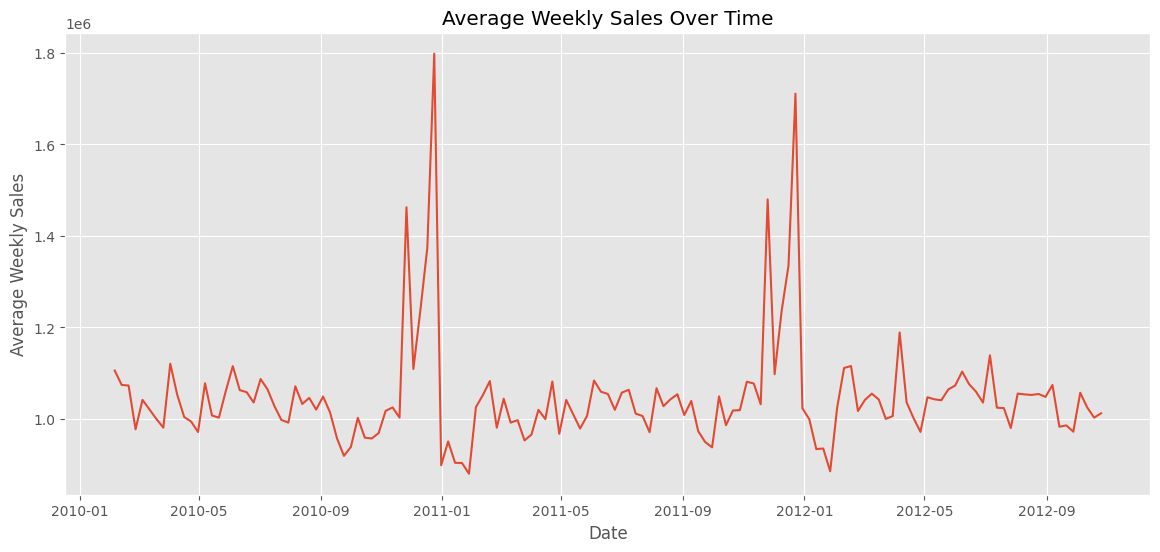

In [48]:
sales_trend = df.groupby("Date")["Weekly_Sales"].mean()

plt.figure(figsize=(14,6))
plt.plot(sales_trend)
plt.title("Average Weekly Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Average Weekly Sales")
plt.show()

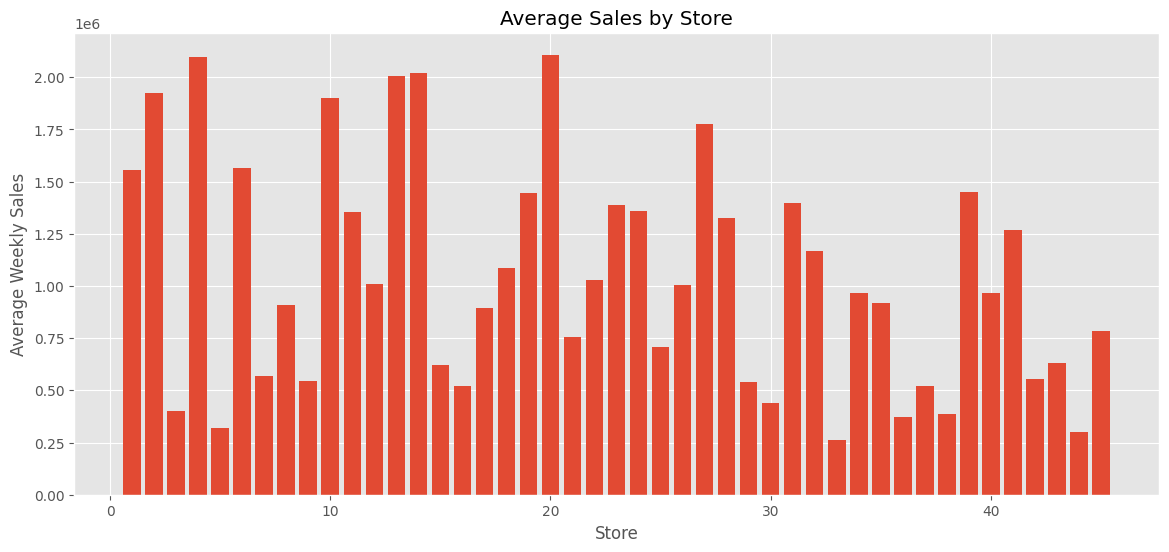

In [49]:
store_sales = df.groupby("Store")["Weekly_Sales"].mean()

plt.figure(figsize=(14,6))
plt.bar(store_sales.index, store_sales.values)
plt.title("Average Sales by Store")
plt.xlabel("Store")
plt.ylabel("Average Weekly Sales")
plt.show()

## Feature Correlation Analysis

In [50]:
df.corr(numeric_only=True)

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,Week
Store,1.000000e+00,-0.335332,-4.386841e-16,-0.022659,0.060023,-0.209492,0.223531,3.474318e-12,2.910676e-15,3.106283e-15
Weekly_Sales,-3.353320e-01,1.000000,3.689097e-02,-0.063810,0.009464,-0.072634,-0.106176,-1.837754e-02,7.614332e-02,7.421127e-02
Holiday_Flag,-4.386841e-16,0.036891,1.000000e+00,-0.155091,-0.078347,-0.002162,0.010960,-5.678257e-02,1.229958e-01,1.277427e-01
Temperature,-2.265908e-02,-0.063810,-1.550913e-01,1.000000,0.144982,0.176888,0.101158,6.426923e-02,2.358618e-01,2.361833e-01
Fuel_Price,6.002295e-02,0.009464,-7.834652e-02,0.144982,1.000000,-0.170642,-0.034684,7.794703e-01,-4.215590e-02,-3.240300e-02
CPI,-2.094919e-01,-0.072634,-2.162091e-03,0.176888,-0.170642,1.000000,-0.302020,7.479573e-02,4.979672e-03,6.041530e-03
Unemployment,2.235313e-01,-0.106176,1.096028e-02,0.101158,-0.034684,-0.302020,1.000000,-2.418135e-01,-1.274559e-02,-1.589158e-02
Year,3.474318e-12,-0.018378,-5.678257e-02,0.064269,0.779470,0.074796,-0.241813,1.000000e+00,-1.944645e-01,-1.819189e-01
Month,2.910676e-15,0.076143,1.229958e-01,0.235862,-0.042156,0.004980,-0.012746,-1.944645e-01,1.000000e+00,9.959843e-01
Week,3.106283e-15,0.074211,1.277427e-01,0.236183,-0.032403,0.006042,-0.015892,-1.819189e-01,9.959843e-01,1.000000e+00


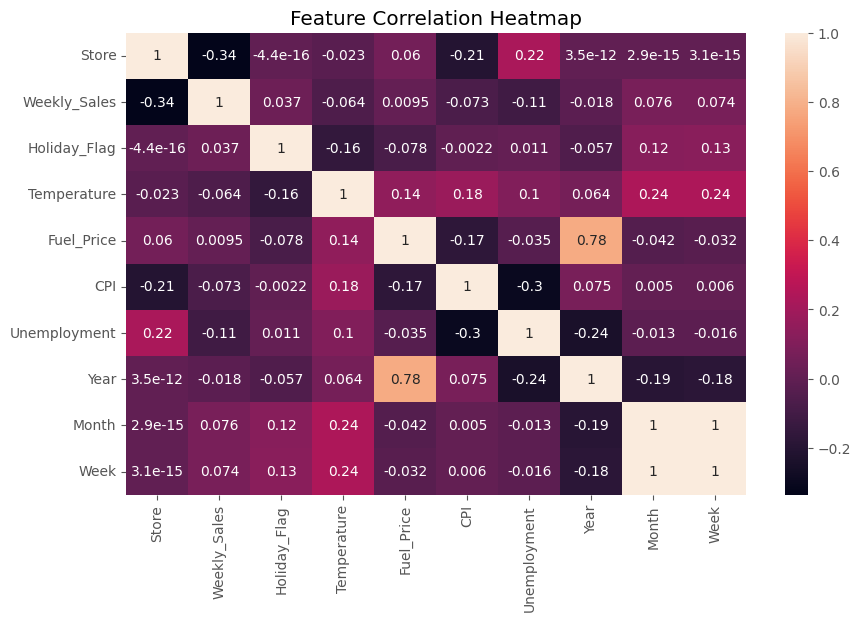

In [51]:
import seaborn as sns

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Feature Correlation Heatmap")
plt.show()

### Observation

Holiday periods show increased weekly sales, indicating that seasonal demand spikes are important for forecasting models.

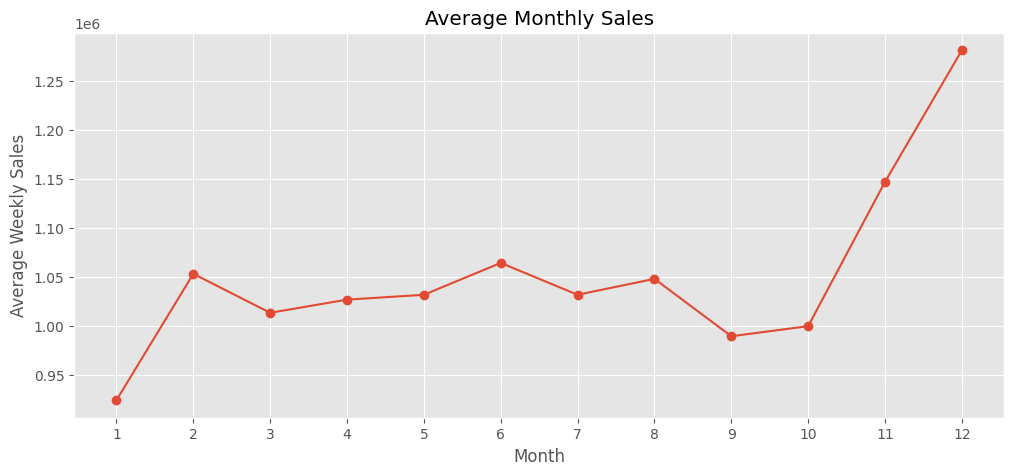

In [52]:
monthly_sales = df.groupby("Month")["Weekly_Sales"].mean()

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")

plt.xticks(range(1,13))

plt.show()

# outlier analysis

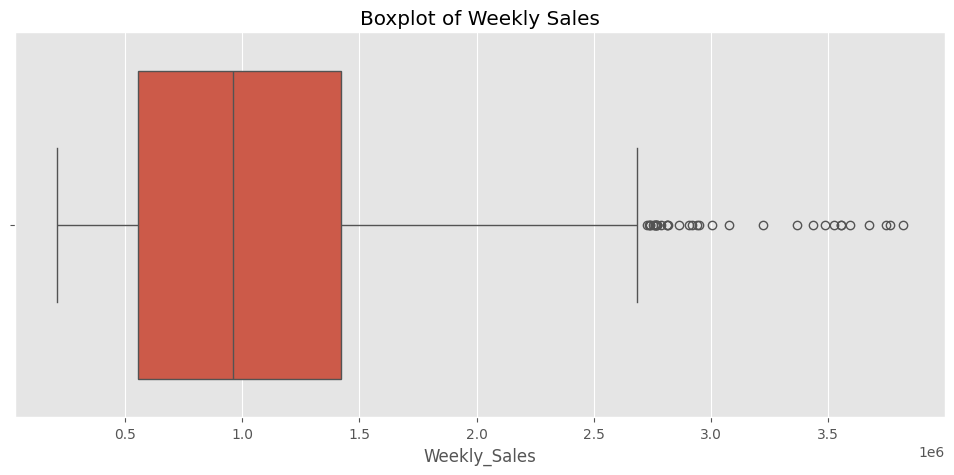

In [53]:
plt.figure(figsize=(12,5))
sns.boxplot(x=df["Weekly_Sales"])
plt.title("Boxplot of Weekly Sales")
plt.show()